In [190]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
from itertools import product
import torch
import numpy as np

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory, UserPaperInteraction
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay

In [184]:
users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
user_list = users_loader.get_users()
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
selector = CitationsSelector()
rater = RuleBasedCitationRater()
reward_shaping = CitationRewardReshapingExpDecay()

## Randomly

In [191]:
env = UserEnv(
        render_mode= "human",
        debug=True,
        debug_path=f"debug_log/user_env_DQN_all_users_random.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,
        render_path="./tmp/render/",
    )
env = Monitor(env, filename=f"monitor_DQN_alluser_random.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
model = DQN("MultiInputPolicy", env, verbose=1, 
                device="cpu",
                buffer_size=20000,
                target_update_interval=500,
                exploration_fraction=0.7,
                learning_starts=1000,
                batch_size=128,
                exploration_final_eps=0.1)
model.learn(total_timesteps=90000)

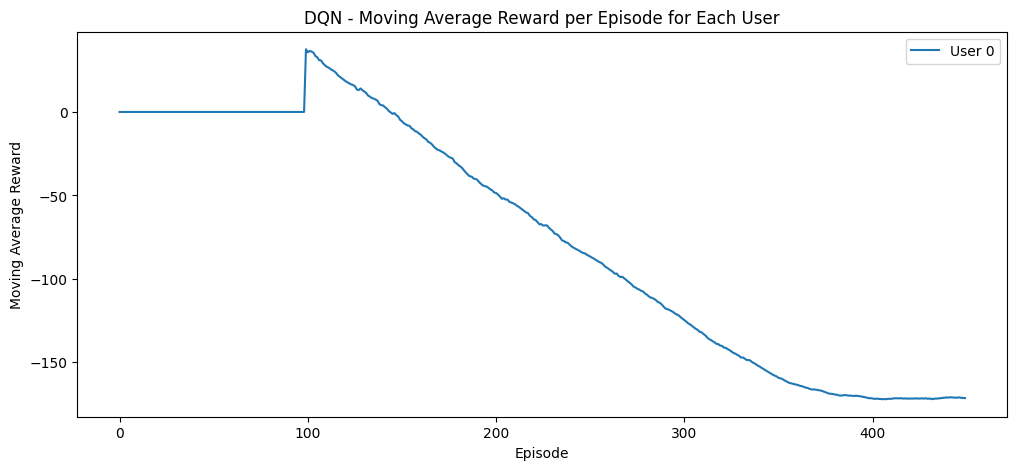

In [192]:
def plot_rewards(all_user_rewards, window_size=100):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"DQN - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/DQN Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards([env.get_episode_rewards()])

In [193]:
import pandas as pd
random_DQN_df = pd.read_csv("monitor_DQN_alluser_random.csv.monitor.csv", skiprows=1)
random_DQN_df

,r,l,t,user_id,item_interact,item_clicks
0,133.148202,200,1.665029,2,"(np.int64(16105), np.int64(27156), np.int64(48...","(1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, ..."
1,-57.954943,200,3.184153,0,"(np.int64(25643), np.int64(13518), np.int64(48...","(0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,78.643967,200,4.716022,6,"(np.int64(28356), np.int64(48483), np.int64(46...","(0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, ..."
3,93.501459,200,6.248139,4,"(np.int64(22177), np.int64(13332), np.int64(21...","(1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, ..."
4,92.054785,200,7.765927,4,"(np.int64(49036), np.int64(17952), np.int64(19...","(1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ..."
...,...,...,...,...,...,...
445,-163.891471,200,1075.526787,5,"(np.int64(23360), np.int64(43574), np.int64(23...","(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
446,-164.073319,200,1077.945980,5,"(np.int64(23360), np.int64(49330), np.int64(23...","(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
447,-187.852222,200,1080.386106,0,"(np.int64(23360), np.int64(49330), np.int64(48...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
448,-191.454276,200,1082.854118,0,"(np.int64(23360), np.int64(25504), np.int64(23...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [196]:
random_DQN_df.groupby('user_id').mean('r')

,r,l,t
user_id,,,
0,-152.136582,200.0,609.418105
1,-74.048400,200.0,523.601870
2,-58.288128,200.0,529.716098
3,-91.747459,200.0,577.076434
4,-61.977375,200.0,473.534477
5,-59.590366,200.0,515.156227
6,-82.750290,200.0,549.663384
7,-91.253770,200.0,508.094541
8,-103.520545,200.0,551.414321


## Hyperparameter Tuning

In [14]:
user_rewards = {}
param_rewards = {}
params_monitor = {}
timesteps = 30000

hyperparameter = {
    "exploration_fraction": [0.6, 0.7, 0.8],
    "learning_starts": [1000, 2000, 5000],
    "batch_size": [64, 128],
    "exploration_final_eps": [0.1, 0.05],
}

param_names = list(hyperparameter.keys())
env = UserEnv(
        render_mode= "human",
        # debug=True,
        # debug_path=f"debug_log/user_env_DQN_all_users_{timesteps}.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
    )

i = 0
for args in product(*hyperparameter.values()):
    i += 1
    params = dict(zip(param_names, args))
    key = tuple(args)
    env = Monitor(env, filename=f"monitor_DQN_alluser_param{i}.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
    
    params_monitor[key] = env

    print(f"Params: {params}")

    model = DQN("MultiInputPolicy", env, verbose=1, 
                device="cpu",
                buffer_size=20000,
                target_update_interval=500,
                **params)
                
    model.learn(total_timesteps=timesteps)
    param_rewards[key] = env.get_episode_rewards()
    # user_rewards[key][user.id].append(env.get_episode_rewards())

# best_params = max(model_rewards, key=lambda p: sum(model_rewards[p]))
# user_best_param[user.id] = best_params
# user_rewards[user.id][best_params] = model_rewards[best_params]

Params: {'exploration_fraction': 0.6, 'learning_starts': 1000, 'batch_size': 64, 'exploration_final_eps': 0.1}
Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 50       |
|    ep_rew_mean      | 16.6     |
|    exploration_rate | 0.99     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 112      |
|    time_elapsed     | 1        |
|    total_timesteps  | 200      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 50       |
|    ep_rew_mean      | 15.9     |
|    exploration_rate | 0.98     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 115      |
|    time_elapsed     | 3        |
|    total_timesteps  | 400      |
----------------------------------
----------------------------------
| rollout/            |         

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:42                                                                                   │
│                                                                                                  │
│   39 │   │   │   │   target_update_interval=500,                                                 │
│   40 │   │   │   │   **params)                                                                   │
│   41 │                                                                                           │
│ ❱ 42 │   model.learn(total_timesteps=timesteps)                                                  │
│   43 │   param_rewards[key] = env.get_episode_rewards()                                          │
│   44 │   # user_rewards[key][user.id].append(env.get_episode_rewards())                          │
│   45                                                                                             │
│                                                                                                  │
│ /Users/monika/SUBER/.venv/lib/python3.9/site-packages/stable_baselines3/dqn/dqn.py:267 in learn  │
│                                                                                                  │
│   264 │   │   reset_num_timesteps: bool = True,                                                  │
│   265 │   │   progress_bar: bool = False,                                                        │
│   266 │   ) -> SelfDQN:                                                                          │
│ ❱ 267 │   │   return super().learn(                                                              │
│   268 │   │   │   total_timesteps=total_timesteps,                                               │
│   269 │   │   │   callback=callback,                                                             │
│   270 │   │   │   log_interval=log_interval,                                                     │
│                                                                                                  │
│ /Users/monika/SUBER/.venv/lib/python3.9/site-packages/stable_baselines3/common/off_policy_algori │
│ thm.py:331 in learn                                                                              │
│                                                                                                  │
│   328 │   │   │   │   gradient_steps = self.gradient_steps if self.gradient_steps >= 0 else ro   │
│   329 │   │   │   │   # Special case when the user passes `gradient_steps=0`                     │
│   330 │   │   │   │   if gradient_steps > 0:                                                     │
│ ❱ 331 │   │   │   │   │   self.train(batch_size=self.batch_size, gradient_steps=gradient_steps   │
│   332 │   │                                                                                      │
│   333 │   │   callback.on_training_end()                                                         │
│   334                                                                                            │
│                                                                                                  │
│ /Users/monika/SUBER/.venv/lib/python3.9/site-packages/stable_baselines3/dqn/dqn.py:220 in train  │
│                                                                                                  │
│   217 │   │   │   loss.backward()                                                                │
│   218 │   │   │   # Clip gradient norm                                                           │
│   219 │   │   │   th.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)      │
│ ❱ 220 │   │   │   self.policy.optimizer.step()                                                   │
│   221 │   │                                                                                      │
│   222 │   │   # Increase update counter                    

In [ ]:
mean_by_param = {}
for params, per_user_rewards in user_rewards.items():
    # per_user_rewards is a dict user_id → list of that user’s episode rewards
    user_means = [sum(rews) / len(rews) for rews in per_user_rewards.values()]
    mean_by_param[params] = sum(user_means) / len(user_means)

# 2) Find the params with the highest overall mean
best_params = max(mean_by_param, key=mean_by_param.get)
best_score  = mean_by_param[best_params]

print(f"Best params: {best_params}, avg reward = {best_score:.3f}")

In [ ]:
best_model = DQN("MultiInputPolicy", env, device="cpu",
                    buffer_size=20000,
                    target_update_interval=500,
                    **best_params)
best_model.save("models/dqn_citation_recommender")

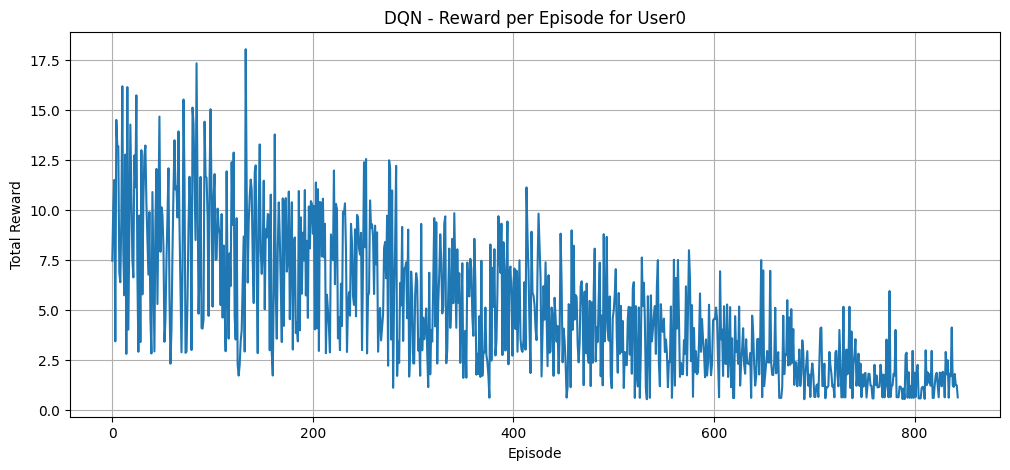

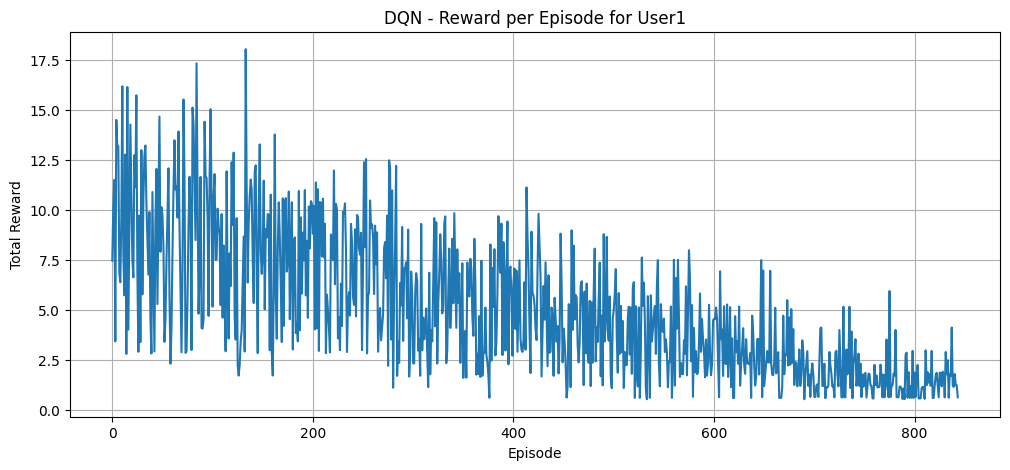

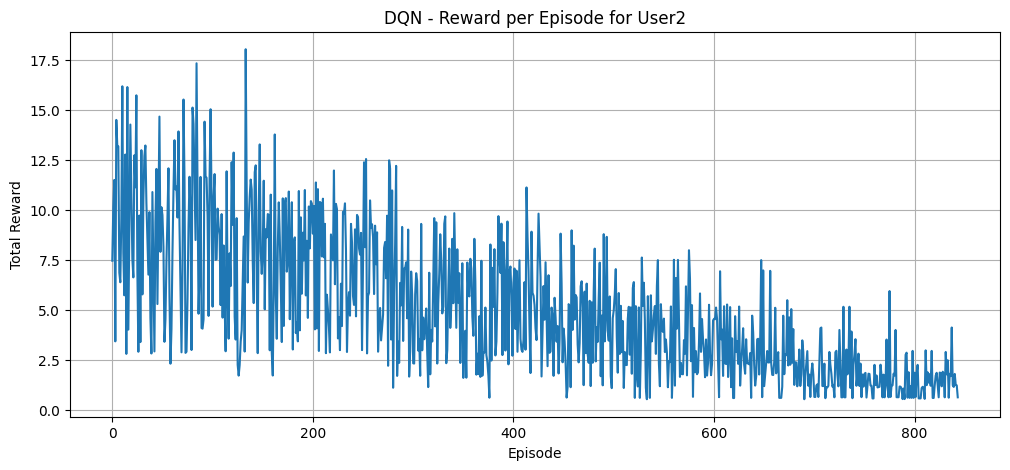

In [30]:
i = 0

for rewards in user_rewards:
    rewards = env.get_episode_rewards()
    plt.figure(figsize=(12, 5))
    plt.plot(rewards)
    plt.title(f"DQN - Reward per Episode for User{i}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True)
    plt.show()

    i += 1

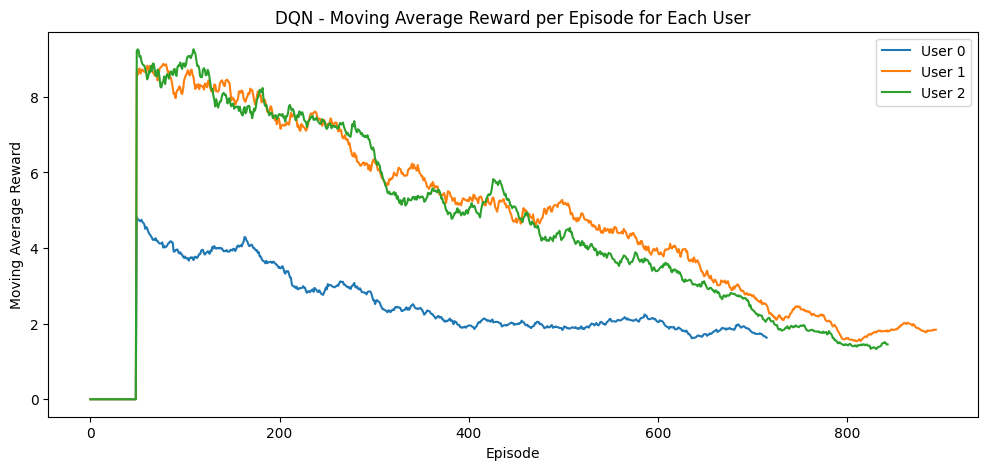

In [60]:
def plot_rewards(all_user_rewards, window_size=50):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"DQN - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/DQN Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards(user_rewards)

In [43]:
import pandas as pd
import re
import ast

In [44]:
def to_int_tuple(s: str):
    # 1) replace np.int64(123) with just 123
    cleaned = re.sub(r'np\.int64\(\s*(\d+)\s*\)', r'\1', s)
    # 2) literal_eval the result to get a Python tuple of ints
    return ast.literal_eval(cleaned)

# apply it to your DataFrame
df = pd.read_csv("monitor_A2C_user0.csv.monitor.csv", skiprows=1)
df['item_interact_tuple'] = df['item_interact'].apply(to_int_tuple)
df['item_clicks_tuple'] = df['item_clicks'].apply(to_int_tuple)

In [45]:
df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].nunique()

22567

In [46]:
interacted_papers_id = df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].unique()
interacted_papers = paper_loader.load_items_from_ids(interacted_papers_id)
recommended_papers = {
    "id": [],
    "title": [],
    "publication_year": [],
    "quartile_year": [],
    "cited_by_count": [],
    "quartile_cite": [],
    "topics": [],
    # "clicked": []
}

for i in range(len(interacted_papers)):
    recommended_papers["id"].append(interacted_papers[i].id)
    recommended_papers["title"].append(interacted_papers[i].title)
    recommended_papers["publication_year"].append(interacted_papers[i].year)
    recommended_papers["quartile_year"].append(interacted_papers[i].quartile_year)
    recommended_papers["cited_by_count"].append(interacted_papers[i].cited_by_count)
    recommended_papers["quartile_cite"].append(interacted_papers[i].quartile_cite)
    recommended_papers["topics"].append(interacted_papers[i].topics)
    # recommended_papers["clicked"].append(df['item_clicks_tuple'][i])

recommended_papers_df = pd.DataFrame(recommended_papers)
recommended_papers_df

,id,title,publication_year,quartile_year,cited_by_count,quartile_cite,topics
0,39906,Chemical Science - the best new journal,2011,0.368687,0,0.000000,"[scientometrics and bibliometrics research, Hi..."
1,40327,Looking for chemistry!,2013,0.464646,0,0.000000,"[scientometrics and bibliometrics research, Ac..."
2,16422,Research productivity: a definition.,1993,0.164983,12,0.797980,"[scientometrics and bibliometrics research, He..."
3,38737,Research Guides: Research Impacts Using Citati...,2011,0.368687,0,0.000000,[scientometrics and bibliometrics research]
4,6432,Is it better or just the same? Article identif...,2006,0.227273,39,0.917172,"[scientometrics and bibliometrics research, Ad..."
...,...,...,...,...,...,...,...
22562,4147,"Finding open access articles using Google, Goo...",2008,0.272727,58,0.944444,"[scientometrics and bibliometrics research, We..."
22563,28207,Exercises in general chemistry and qualitative...,1927,0.031221,0,0.000000,[scientometrics and bibliometrics research]
22564,4175,How Scholarly Is Google Scholar? A Comparison ...,2009,0.303030,55,0.941919,"[scientometrics and bibliometrics research, Re..."
22565,31741,Open access: requirements for researchers,2016,0.626263,0,0.000000,[scientometrics and bibliometrics research]


## Diversity

In [51]:
from sklearn.decomposition import PCA
import numpy as np
from sentence_transformers import SentenceTransformer

In [48]:
dataset = pd.read_csv("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
sampled_dataset = dataset.sample(
    n=recommended_papers_df.shape[0],
    replace=True,                      # allow repeats
    weights='cited_by_count',          # use this column as relative weights
    random_state=42
)

### Topics

In [52]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")
all_embeddings = []
for topics in recommended_papers_df['topics']:
    # get each topic’s 384‑d vector
    vecs = bert_model.encode(topics, convert_to_tensor=False)
    avg = np.mean(vecs, axis=0)
    all_embeddings.append(avg)

embeddings = np.vstack(all_embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

recommended_papers_df['x'] = coords[:, 0]
recommended_papers_df['y'] = coords[:, 1]

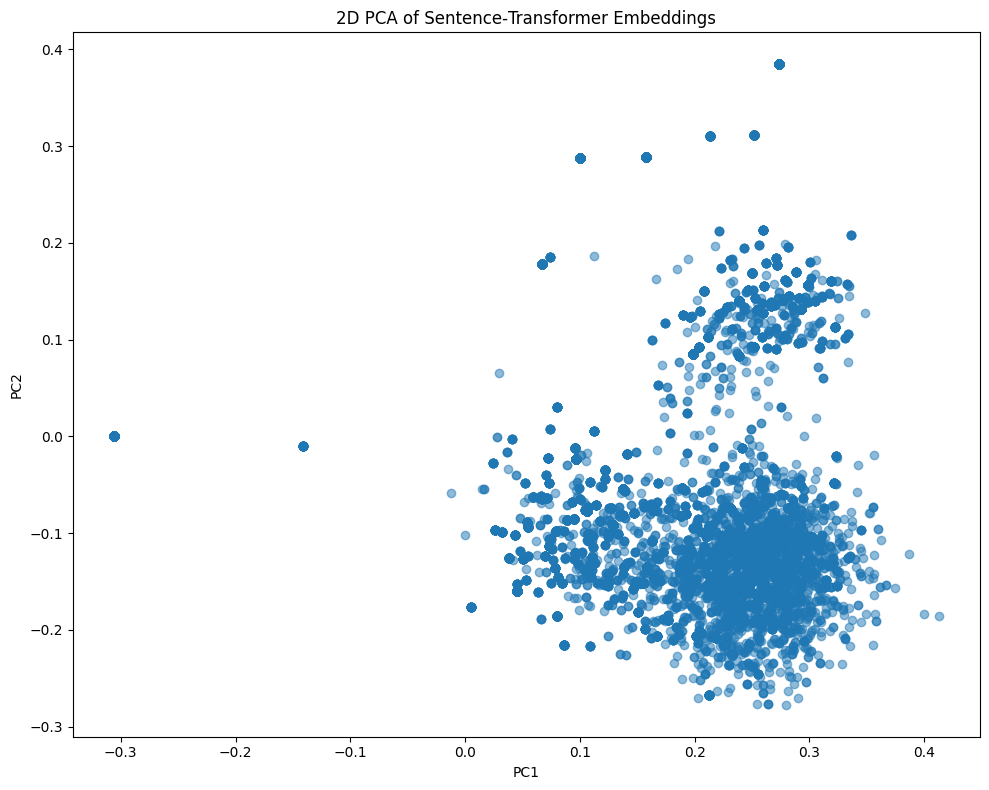

In [54]:
plt.figure(figsize=(10, 8))
plt.scatter(recommended_papers_df['x'], recommended_papers_df['y'], alpha=0.5)
plt.title("2D PCA of Sentence‑Transformer Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### Novelty

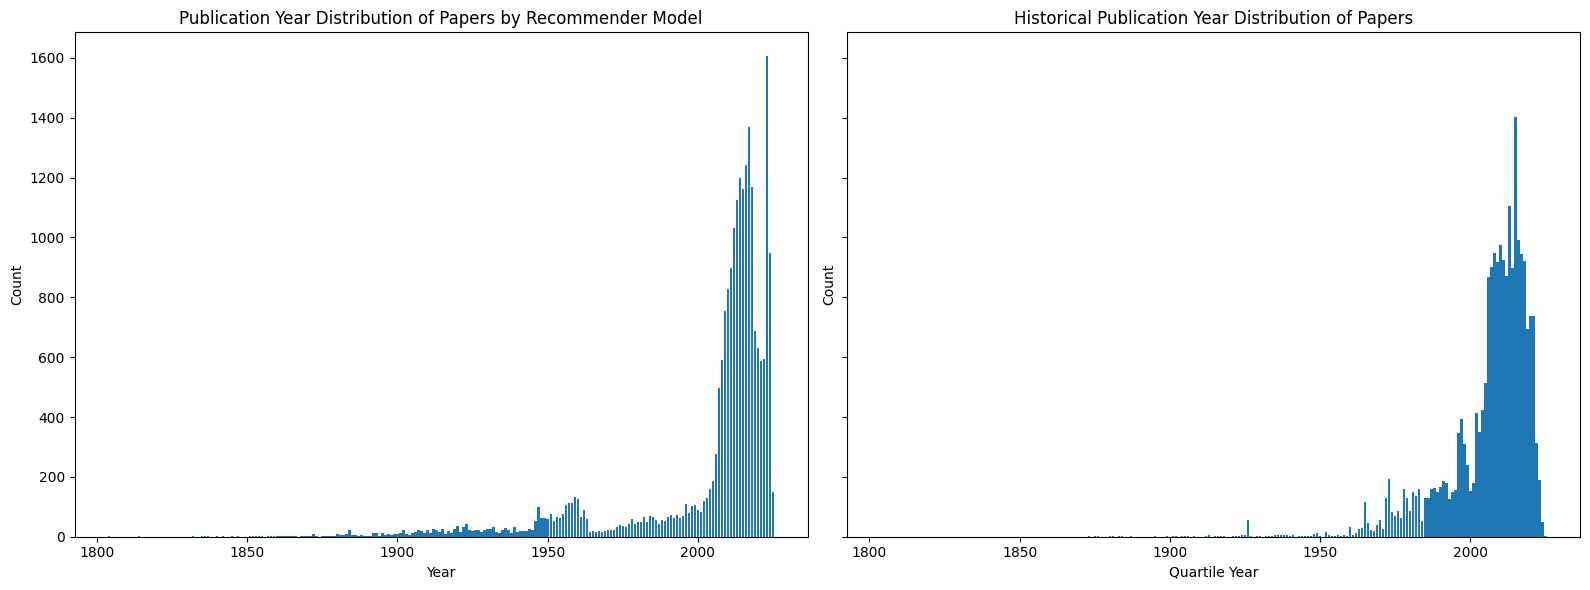

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")

ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
ax2.set_title("Historical Publication Year Distribution of Papers")
ax2.set_xlabel("Quartile Year")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Reputability

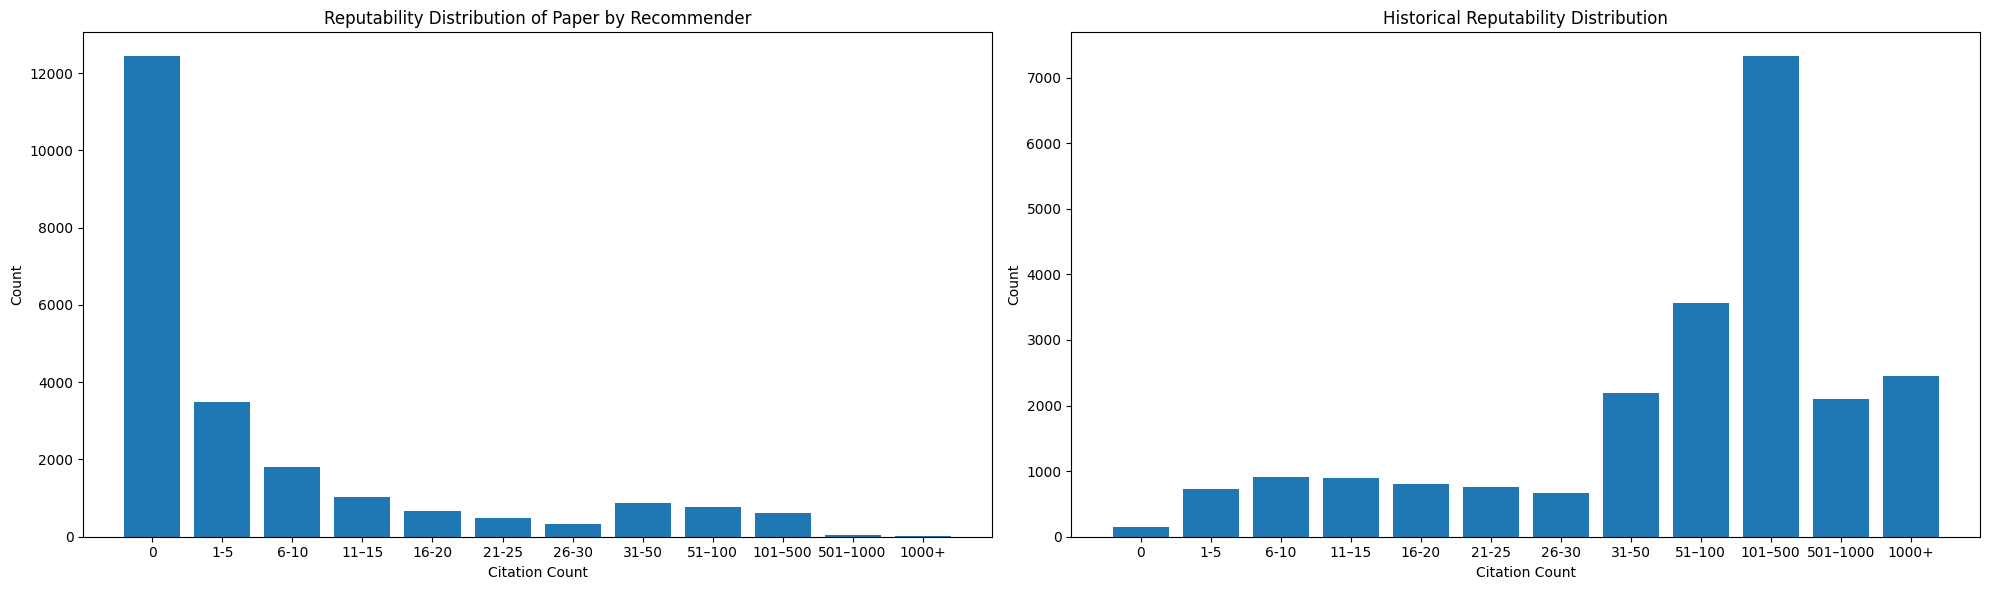

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

bins = [0, 1, 5, 10, 15, 20, 25, 30, 50, 100, 500, 1000, recommended_papers_df['cited_by_count'].max()]
labels = ['0', '1-5', '6-10', '11–15', '16-20', '21-25', '26-30', '31-50', '51–100', '101–500', '501–1000', '1000+']

cited_by_count = pd.cut(recommended_papers_df['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax1.bar(cited_by_count.index, cited_by_count.values)
ax1.set_title("Reputability Distribution of Paper by Recommender")
ax1.set_xlabel("Citation Count")
ax1.set_ylabel("Count")

dataset_cited_by_count = pd.cut(sampled_dataset['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax2.bar(dataset_cited_by_count.index, dataset_cited_by_count.values)
ax2.set_title("Historical Reputability Distribution")
ax2.set_xlabel("Citation Count")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Overall

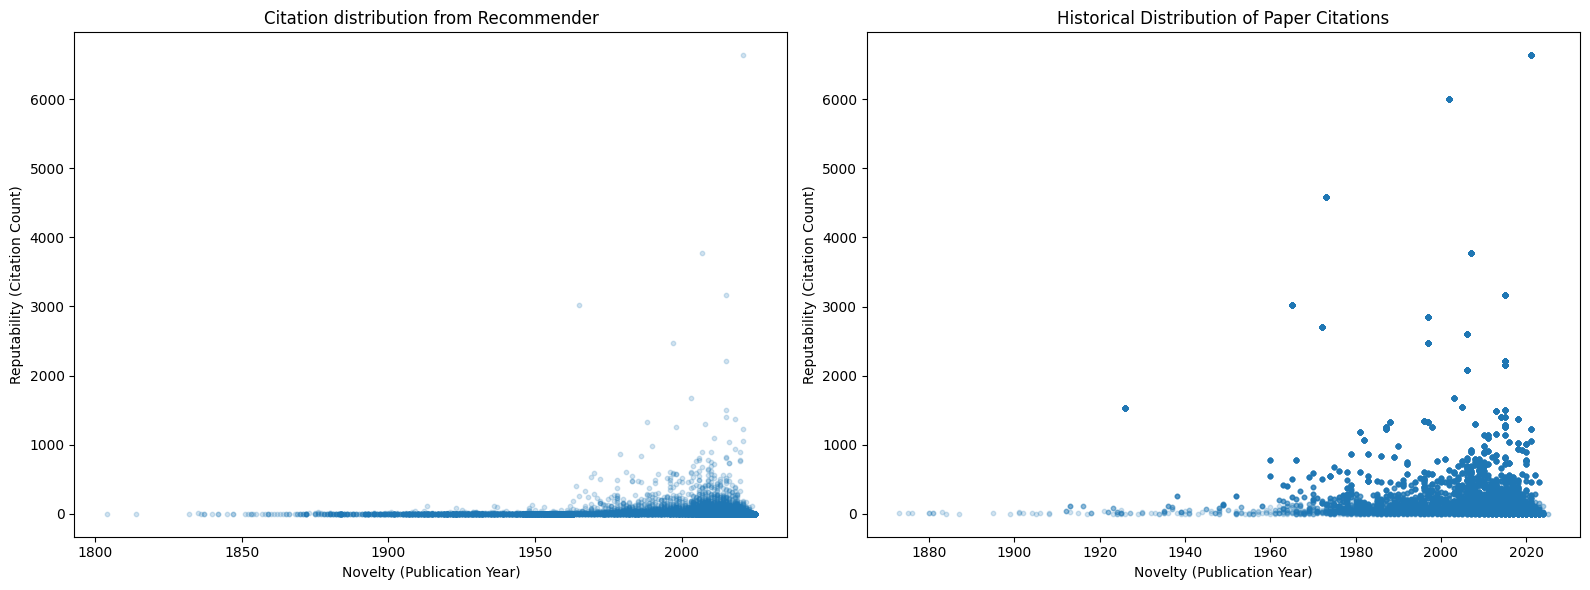

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(recommended_papers_df['publication_year'], recommended_papers_df['cited_by_count'], alpha=0.2, s=10)
ax1.set_title("Citation distribution from Recommender")
ax1.set_xlabel("Novelty (Publication Year)")
ax1.set_ylabel("Reputability (Citation Count)")

ax2.scatter(sampled_dataset['publication_year'], sampled_dataset['cited_by_count'], alpha=0.2, s=10)
ax2.set_title("Historical Distribution of Paper Citations")
ax2.set_xlabel("Novelty (Publication Year)")
ax2.set_ylabel("Reputability (Citation Count)")

plt.tight_layout()
plt.show()

# Evaluation

In [100]:
eval_users_loader = CitationUsersLoader("../environment/users/datasets/user_eval.json")
all_users = eval_users_loader.get_users()

env = UserEnv(
        render_mode= "human",
        debug=False,
        items_loader=paper_loader,
        user_list=all_users,
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
)
env = Monitor(env, filename=f"monitor_DQN_user_eval.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
model = DQN.load("models/dqn_citation_recommender", env=env, device="cpu")

user_rewards = {}
user_interacted_papers = {}

for user in all_users:
    if user.id not in user_rewards:
        user_rewards[user.id] = []
        user_interacted_papers[user.id] = []

    obs, info = env.reset(user_id=user.id)
    terminated = False
    current_user_reward = []
    
    while not terminated:
        action, next_obs = model.predict(obs, deterministic=True)
        obs, reward, terminated, _, info = env.step(action=int(action))
        user_rewards[user.id].append(reward)
        user_interacted_papers[user.id].append(int(action))

In [101]:
action

array(12792)

In [102]:
user_rewards

{9: [0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 10: [np.float64(0.5913216765412516),
  np.float64(0.005913216765412517),
  np.float64(0.0005913216765412517),
  np.float64(5.913216765412517e-05),
  np.float64(5.913216765412517e-06),
  np.float64(5.913216765412517e-07),
  np.float64(5.913216765412518e-08),
  np.float64(5.913216765412519e-09),
  np.float64(5.913216765412518e-10),
  np.float64(5.913216765412518e-11),
  np.float64(5.913216765412519e-12),
  np.float64(5.91321676541252e-13),
  np.float64(5.91321676541252e-14),
  np.float64(5.91321676541252e-15),
  np.float64(5.913216765412521e-16),
  np.float64(5.913216765412521e-17),
  np.float64(5.913216765412522e-18),
  np.float64(5.9132167

In [104]:
user_interacted_papers

{9: [12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792],
 10: [12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792],
 11: [12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  12792,
  1279